# 07 — ML Model Selection & Ensemble Building

Loads pre-computed forward recursive feature selection results and builds ensemble ML models (VotingRegressor over Kernel Ridge, MLP, and Random Forest pipelines) used for all predictions.

## Prerequisites / Input files
- `Fe-Mo/results/concatenation_results_EF_nmhcp_*.pkl` — feature selection results (included in repo)
- `Fe-Mo/results/voting_regressor_*.pkl` — fitted ensemble models

## Outputs
- `Fe-Mo/results/Fe-Mo_*_OptimalScores_EF_nmhcp.pkl`
- `Fe-Mo/graphs/` — learning curve and prediction figures

## Notes
> The `concatenation_results_*.pkl` files encode the output of forward recursive feature selection runs performed on a compute cluster using `Scripts/FeatureSelection.py`. They are included in the repository and do not need to be recomputed.



# ML from DFT data

In [167]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold
import joblib
import matplotlib
from matplotlib.ticker import FormatStrFormatter
from Tools.DatasetTools.MLConveniences import *
import os

In [168]:
import logging
Logger = logging.getLogger()
Logger.setLevel(logging.INFO)

# Parameters 

In [ ]:
target_case = 'EF_nmhcp'

# Stable execution mode for Run All in VS Code notebooks.
STABLE_MODE = True
CALC_IMPORTANCES = 'CALC_IMPORTANCES'
MODELNAME = 'MODELNAME'

For training, we take only TCP phases

In order to delegate dataset-feature alignment and stratified splitting by phases, we create Dataset object

In [170]:
DS = Dataset(
    'Fe-Mo',
    target_name=target_case,
    remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"', 
#    load_features_only=['dataset','SOAP_specific_small']
    )

In [171]:
DS.BS.index

Index(['Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBABB.FM', 'Fe_pv8Mo_sv22.sigma-BBBAB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv4Mo_sv20.C36-BBABB.NM',
       'Fe_pv2Mo_sv10.C14-BAB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv1Mo_sv12.mu-ABBBB.NM',
       ...
       'Mo_sv24.C36.FM', 'Mo_sv29.chi.FM', 'Fe_pv4Mo_sv2.C15-A2B.FM',
       'Fe_pv6Mo_sv2.A15-AB.NM', 'Fe_pv8Mo_sv16.C36-BAABB.NM',
       'Fe_pv30.sigma.FM', 'Fe_pv6.C15.FM', 'Mo_sv8.A15.NM', 'Mo_sv6.C15.NM',
       'Fe_pv12.C14.FM'],
      dtype='object', length=262)

In [172]:
for featurename,feature in DS.Features.items():
    logging.info (f'{featurename}, {len(feature)}')

INFO:root:atomic, 262
INFO:root:dataset, 262
INFO:root:SOAP_specific_small, 262
INFO:root:ACE, 262
INFO:root:Canonical ACE, 262
INFO:root:Canonical BOP, 261
INFO:root:0.7dProjections 0.5OS BOP, 261
INFO:root:dataset + Canonical BOP, 262
INFO:root:dataset + 0.7dProjections 0.5OS BOP, 262
INFO:root:atomic no CNAV, 262
INFO:root:dataset no CNAV, 262
INFO:root:SOAP_specific_small no CNAV, 262
INFO:root:ACE no CNAV, 262
INFO:root:Canonical ACE no CNAV, 262
INFO:root:Canonical BOP no CNAV, 261
INFO:root:0.7dProjections 0.5OS BOP no CNAV, 261
INFO:root:dataset + Canonical BOP no CNAV, 262
INFO:root:dataset + 0.7dProjections 0.5OS BOP no CNAV, 262


In [173]:
DS.Features['0.7dProjections 0.5OS BOP'].index.symmetric_difference(DS.BS.index)

Index(['Fe_pv12.C14.FM'], dtype='object')

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [174]:
if MODELNAME not in os.environ:
    ModelName = 'Kernel Ridge'
    logging.info(f'Model Name = {ModelName}')
else:
    ModelName = os.environ[MODELNAME]
    logging.info(f'ModelName = {ModelName}')

INFO:root:Model Name = Kernel Ridge


In [175]:
namefile = ModelName.replace(' ', '')

In [176]:
suffix = f"no_hcp_bcc_fcc_{namefile}" #'CV_restart_folds_inloop''CV_restart_folds_inloop

In [177]:
(DS.BS.Phase == 'hcp').sum()

0

# Targets

In [178]:
plt.rc('text', usetex=False)

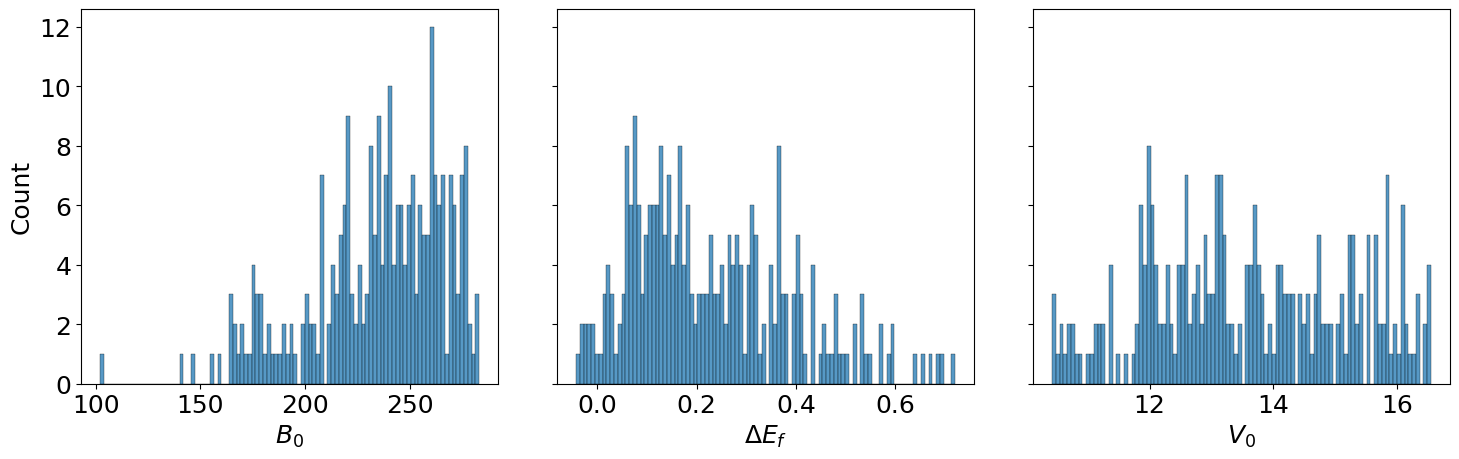

In [179]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [180]:
DS.BS.B0.idxmax()

'Fe_pv4Mo_sv2.C15-A2B.NM'

In [181]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137580,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,29,0,29,1.0,0.0,FM,chi,0.117648,0.117648,0.117648
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.0,0.0,FM,C15,0.144169,0.144169,0.144169
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,12,0,12,1.0,0.0,FM,C14,0.149237,0.149237,0.149237


# Machine Learning 

In [182]:
resultslocation = DS.resultslocation

## Feature sets

In [183]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [184]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [185]:
for name, featuredf in Features.items():
    if 'BOP' in name:
        print (name )

Canonical BOP
0.7dProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV


## test - train splits

stratified splitting makes test-train splits ratios constant for all phases

In [186]:
samplesplit = DS.get_samplesplit()

In [187]:
len(samplesplit['test'])

53

In [188]:
len(samplesplit['train'])

209

In [189]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv30.sigma.FM,bulk sigma.FM,11.888048 A,-8.179970,144.498096 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.019,0,1,...,30,0,30,1.000000,0.000000,FM,sigma,0.075258,0.075258,0.075258
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv6.C15.NM,bulk C15,16.457210 A,-10.565358,234.041146 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.014,0,1,...,6,0,6,0.000000,1.000000,NM,C15,0.367463,0.367463,0.367463


<Axes: xlabel='Structure', ylabel='Count'>

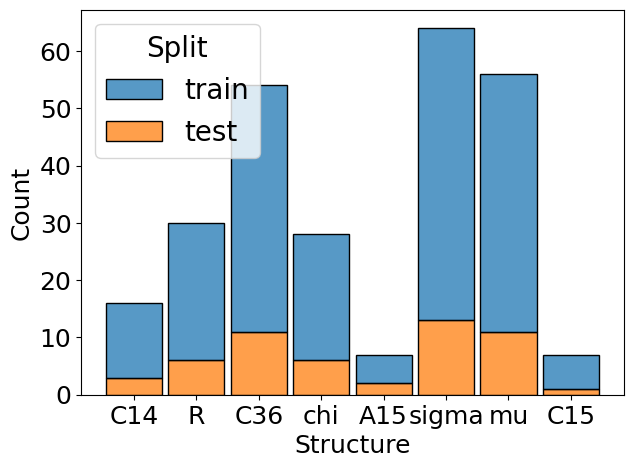

In [190]:
train_structures = DS.StructureNames.loc[samplesplit['train']]
test_structures = DS.StructureNames.loc[samplesplit['test']]

plot_df = {
    'Structure': list(train_structures) + list(test_structures),
    'Split': ['train'] * len(train_structures) + ['test'] * len(test_structures),
}

sns.histplot(data=plot_df, x='Structure', hue='Split', multiple='stack', shrink=0.9)

# Models: adjust params

In [191]:
import warnings
warnings.simplefilter('ignore')

In [192]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [193]:
from Tools.DatasetTools.ModelSelection import ModelOptions

In [194]:
from importlib.machinery import SourceFileLoader
#MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)
MO = ModelOptions(DS.dataset)

In [195]:
MO.load_model_options(ModelName)

In [196]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [197]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index([], dtype='object')

In [198]:
test_bop_feature = '0.7dProjections 0.5OS BOP'

In [199]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [200]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [201]:
DS.target.index.difference(Features[test_bop_feature].index)

Index(['Fe_pv12.C14.FM'], dtype='object')

In [202]:
for name, thefeatures in Features.items():
    logging.info(f'{name}, {thefeatures.shape}')

INFO:root:atomic, (262, 135)
INFO:root:dataset, (262, 32)
INFO:root:SOAP_specific_small, (262, 287)
INFO:root:ACE, (262, 1803)
INFO:root:Canonical ACE, (262, 417)
INFO:root:Canonical BOP, (261, 405)
INFO:root:0.7dProjections 0.5OS BOP, (261, 417)
INFO:root:dataset + Canonical BOP, (262, 436)
INFO:root:dataset + 0.7dProjections 0.5OS BOP, (262, 448)
INFO:root:atomic no CNAV, (262, 135)
INFO:root:dataset no CNAV, (262, 19)
INFO:root:SOAP_specific_small no CNAV, (262, 76)
INFO:root:ACE no CNAV, (262, 303)
INFO:root:Canonical ACE no CNAV, (262, 72)
INFO:root:Canonical BOP no CNAV, (261, 70)
INFO:root:0.7dProjections 0.5OS BOP no CNAV, (261, 72)
INFO:root:dataset + Canonical BOP no CNAV, (262, 86)
INFO:root:dataset + 0.7dProjections 0.5OS BOP no CNAV, (262, 88)


In [203]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

# Feature Selection

Forward recursive feature selection is probably quite demanding. we provide Feature selection for visualization.
The process can anyway be reproduced by executing on the terminal:

```
python Tools/ExecuteFeatureConcatenate.py KernelRidge nprocs
```

where nprocs is number of processors for paralelization

In [204]:
suffix

'no_hcp_bcc_fcc_KernelRidge'

In [205]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        savedFCresults = pickle.load(pkl)
else:
    savedFCresults = {}

In [206]:
#with open(feature_concat_resul_loc, 'wb') as f:
#    pickle.dump(savedFCresults, f)

In [207]:
FCresults = {}

In [208]:
for combi, selectionloop in savedFCresults.items():
    print (combi, len(selectionloop))
    FCresults[combi] = []
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
            thisloop=thisloop.loc[:'random'].iloc[:-1]
        else:
            print (badnews, len(thisloop))
        if len(thisloop) < 1:
            continue
        FCresults[combi].append(thisloop)

('Kernel Ridge', 'atomic') 3
False 8
False 8
False 8
('Kernel Ridge', 'dataset') 3
False 21
False 8
False 17
('Kernel Ridge', 'Canonical ACE') 12
False 202
False 199
False 132
True 95 / 203
True 143 / 201
False 198
False 198
True 200 / 201
True 148 / 197
True 3 / 77
True 63 / 203
True 78 / 200
('Kernel Ridge', 'Canonical BOP') 13
False 18
False 51
False 145
False 206
False 100
False 150
False 55
False 122
False 112
False 163
False 59
False 171
True 36 / 195
('Kernel Ridge', 'ACE no CNAV') 10
False 105
False 101
False 44
False 60
False 75
False 88
False 114
False 84
False 96
False 129
('Kernel Ridge', 'ACE') 12
False 208
False 220
False 215
False 98
False 242
False 251
False 248
False 251
False 251
False 251
False 251
False 228
('Kernel Ridge', '0.7dProjections 0.5OS BOP') 12
False 134
False 192
False 131
False 126
False 122
False 176
False 192
False 126
False 132
False 205
True 7 / 199
False 185
('Kernel Ridge', '0.7spProjections 0.5OS BOP') 13
False 133
False 106
False 175
False 188
F

In [209]:
for combi, selectionloop in FCresults.items():
    print (combi)
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
        else:
            print(badnews, len (thisloop))

('Kernel Ridge', 'atomic')
False 8
False 8
False 8
('Kernel Ridge', 'dataset')
False 21
False 8
False 17
('Kernel Ridge', 'Canonical ACE')
False 202
False 199
False 132
False 95
False 143
False 198
False 198
False 200
False 148
False 3
False 63
False 78
('Kernel Ridge', 'Canonical BOP')
False 18
False 51
False 145
False 206
False 100
False 150
False 55
False 122
False 112
False 163
False 59
False 171
False 36
('Kernel Ridge', 'ACE no CNAV')
False 105
False 101
False 44
False 60
False 75
False 88
False 114
False 84
False 96
False 129
('Kernel Ridge', 'ACE')
False 208
False 220
False 215
False 98
False 242
False 251
False 248
False 251
False 251
False 251
False 251
False 228
('Kernel Ridge', '0.7dProjections 0.5OS BOP')
False 134
False 192
False 131
False 126
False 122
False 176
False 192
False 126
False 132
False 205
False 7
False 185
('Kernel Ridge', '0.7spProjections 0.5OS BOP')
False 133
False 106
False 175
False 188
False 149
False 179
False 144
False 239
False 115
False 104
False 7

In [210]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')])

In [211]:
for combi, results in FCresults.items():
#    if 'SOAP' in combi[1]:
    print (combi, len(results))

('Kernel Ridge', 'atomic') 3
('Kernel Ridge', 'dataset') 3
('Kernel Ridge', 'Canonical ACE') 12
('Kernel Ridge', 'Canonical BOP') 13
('Kernel Ridge', 'ACE no CNAV') 10
('Kernel Ridge', 'ACE') 12
('Kernel Ridge', '0.7dProjections 0.5OS BOP') 12
('Kernel Ridge', '0.7spProjections 0.5OS BOP') 13
('Kernel Ridge', 'atomic no CNAV') 10
('Kernel Ridge', 'dataset no CNAV') 10
('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV') 10
('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV') 10
('Kernel Ridge', 'SOAP_specific_small') 10
('Kernel Ridge', 'SOAP_specific_small no CNAV') 10
('Kernel Ridge', 'Canonical ACE no CNAV') 10
('Kernel Ridge', 'Canonical BOP no CNAV') 64
('Kernel Ridge', 'SOAP_canonicalW_small') 10
('Kernel Ridge', 'SOAP_canonicalW_small no CNAV') 10
('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP') 1
('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV') 1
('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP') 0
('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNA

In [212]:
nowantoplot = [''] # ['0.6dProjections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [213]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

## Number of curves for each regressor

In [214]:
for featurename in iwanttoplot:
    print(featurename, len(FCresults[(ModelName, featurename)]))

atomic 3
dataset 3
Canonical ACE 12
Canonical BOP 13
ACE no CNAV 10
ACE 12
0.7dProjections 0.5OS BOP 12
0.7spProjections 0.5OS BOP 13
atomic no CNAV 10
dataset no CNAV 10
0.7dProjections 0.5OS BOP no CNAV 10
0.7spProjections 0.5OS BOP no CNAV 10
SOAP_specific_small 10
SOAP_specific_small no CNAV 10
Canonical ACE no CNAV 10
Canonical BOP no CNAV 64
SOAP_canonicalW_small 10
SOAP_canonicalW_small no CNAV 10
0.7dProjections 10scf 8.0jii BOP 1
0.7dProjections 10scf 8.0jii BOP no CNAV 1


In [215]:
iwanttoplot

['atomic',
 'dataset',
 'Canonical ACE',
 'Canonical BOP',
 'ACE no CNAV',
 'ACE',
 '0.7dProjections 0.5OS BOP',
 '0.7spProjections 0.5OS BOP',
 'atomic no CNAV',
 'dataset no CNAV',
 '0.7dProjections 0.5OS BOP no CNAV',
 '0.7spProjections 0.5OS BOP no CNAV',
 'SOAP_specific_small',
 'SOAP_specific_small no CNAV',
 'Canonical ACE no CNAV',
 'Canonical BOP no CNAV',
 'SOAP_canonicalW_small',
 'SOAP_canonicalW_small no CNAV',
 '0.7dProjections 10scf 8.0jii BOP',
 '0.7dProjections 10scf 8.0jii BOP no CNAV']

In [216]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [217]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [218]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [219]:
FittedGS = {}

In [220]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

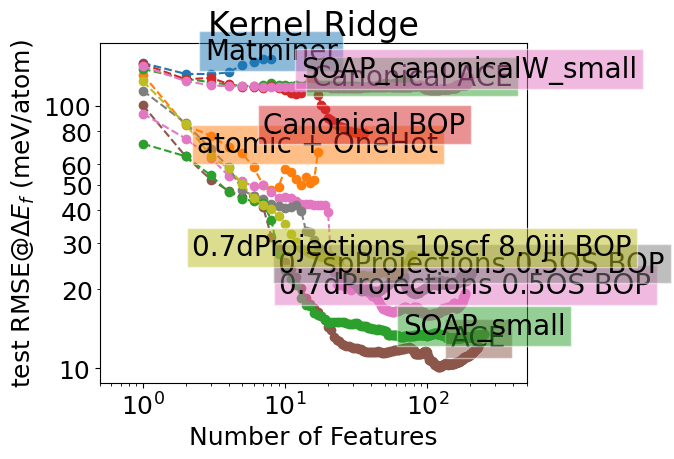

In [221]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    if 'test' not in result[-1].keys():
        continue
    y = result[-1]['test'].values*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log', subs = [0.2, 0.3, 0.4,0.5, 0.6, 0.8])
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_{nameforfile}.pdf')

In [222]:
'Mag' in FCresults[(ModelName, test_bop_feature )][-1].index

True

In [223]:
#'Structure' in
theindex = FCresults[(ModelName, test_bop_feature )][-1].index

In [224]:
FCresults[(ModelName, test_bop_feature )][-1].reset_index()[theindex=='Structure']

,index,train1,test1,params,test,train


In [225]:
combi = (ModelName, test_bop_feature)
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

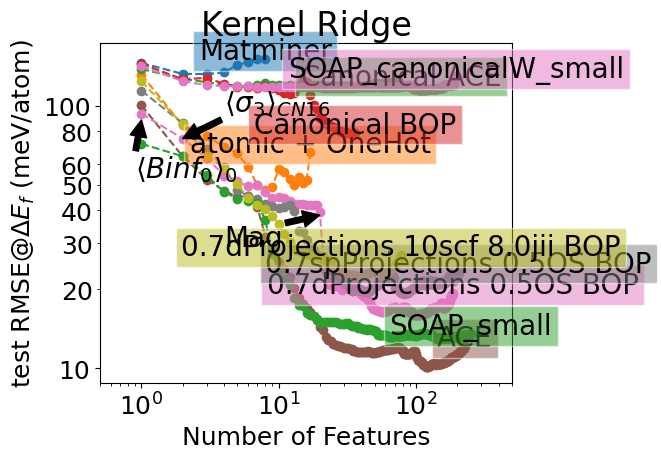

In [226]:
fig

## Feature Selection

In [227]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [228]:
iwanttoplot_all = {
    test_bop_feature: 'BOP',  
    'ACE':'ACE',
    'SOAP_specific_small': 'SOAP',
#    'dataset': 'atomic + OneHot', 
    'Canonical BOP': 'Canonical BOP',
#    'SOAP_canonicalW_small' : 'Canonical SOAP',
#    'Canonical ACE': 'Canonical ACE'
}

In [229]:
iwanttoplot_all

{'0.7dProjections 0.5OS BOP': 'BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP',
 'Canonical BOP': 'Canonical BOP'}

In [230]:
DS.Features.keys()


dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [231]:
def plot_panel_learning_curves(feature_list: dict):# -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = plt.rcParams['figure.figsize'][0]*(3/5)*nplots
    height = plt.rcParams['figure.figsize'][1]
    fig, axes = plt.subplots(1,nplots, figsize=(width, height), sharey = True)# figsize=(width, 5*width/13),
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            if 'test' not in result.keys():
                continue
            sns.scatterplot(x=x, y=result['test']*1000, ax=ax)
        N = Features[featurename].shape[1]
        NL = len(results)
        ax.legend([],[],title=f'N = {N}\n NL = {NL}')
        ax.set_yscale('log', subs=[2, 6, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

In [232]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [233]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')])

In [234]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [235]:
iwanttoplot_all

{'0.7dProjections 0.5OS BOP': 'BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP',
 'Canonical BOP': 'Canonical BOP'}

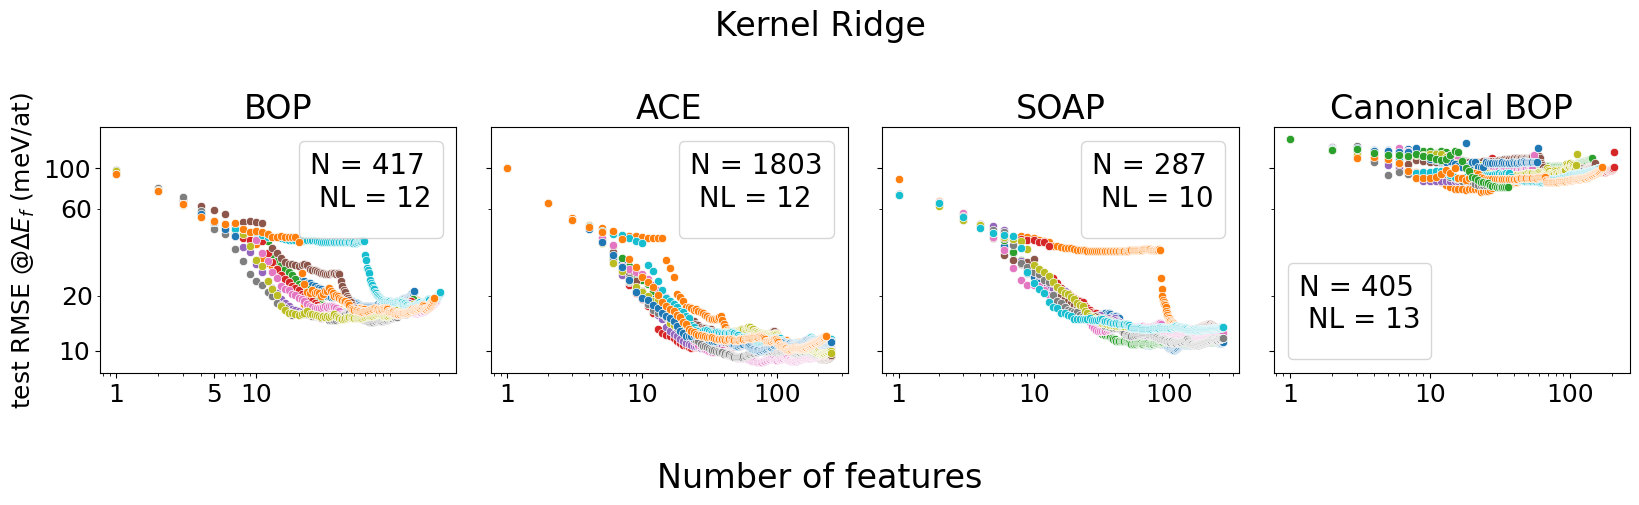

In [236]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.suptitle(ModelName)
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

# Feature transformers

Once the Features are selected, we define Ensemble regression incorporating feature selection to ml pipelines

In [237]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin
from Tools.DatasetTools.MLConveniences import filter_features, get_optimal_features

In [238]:
from sklearn.ensemble import VotingRegressor

In [239]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [240]:
combi = (ModelName, test_bop_feature)

In [241]:
RegresorsBag = {}

## Voting Regressor based on regressor bag

In [242]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

In [243]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [244]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')])

In [245]:
for combi, learningcurvelist in FCresults.items():
    if combi[1] not in Features.keys():
        continue
    for i, learningcurve in enumerate(learningcurvelist):
        intersection = Features[combi[1]].columns.intersection(learningcurve.index)
        print(f'learning curve {i} from {combi} generates {len(intersection)} transform')
        if len(intersection) == 1:
            print(intersection)


learning curve 0 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 1 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 2 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 0 from ('Kernel Ridge', 'dataset') generates 21 transform
learning curve 1 from ('Kernel Ridge', 'dataset') generates 8 transform
learning curve 2 from ('Kernel Ridge', 'dataset') generates 17 transform
learning curve 0 from ('Kernel Ridge', 'Canonical ACE') generates 202 transform
learning curve 1 from ('Kernel Ridge', 'Canonical ACE') generates 199 transform
learning curve 2 from ('Kernel Ridge', 'Canonical ACE') generates 132 transform
learning curve 3 from ('Kernel Ridge', 'Canonical ACE') generates 95 transform
learning curve 4 from ('Kernel Ridge', 'Canonical ACE') generates 143 transform
learning curve 5 from ('Kernel Ridge', 'Canonical ACE') generates 198 transform
learning curve 6 from ('Kernel Ridge', 'Canonical ACE') generates 198 transform
learning c

In [246]:
FCresults[ModelName,  'ACE' ][0]

,train1,test1,params,test,train
ace_projections_110_CN12,0.095755,0.100849,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.100403,0.096607
ace_projections_21_0,0.060231,0.065643,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.064341,0.062708
ace_projections_0_CN12,0.042960,0.063860,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.052067,0.050637
Mag,0.032511,0.058962,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.046954,0.042199
ace_projections_13_CN15,0.017501,0.056231,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.040228,0.039368
...,...,...,...,...,...
ace_projections_200_CN12,0.000032,0.057502,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.010454,0.008954
ace_projections_132_CN12,0.000033,0.057582,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.010473,0.008971
ace_projections_164_0,0.000033,0.057759,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.010498,0.009000
ace_projections_281_CN12,0.000033,0.057766,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.010517,0.009022


In [247]:
from sklearn.utils.validation import check_is_fitted

We provide a pre fitted voting regressor for testing

In [248]:
recreate_voting_regressor = False

In [249]:

if recreate_voting_regressor:
    for combi, LearningCurveList in FCresults.items():
        #if True:
        #    continue
        Logger.info(f'{combi}')
        RegresorsBag[combi] = []
        if combi[1] not in Features:
            continue
        X = Features[combi[1]]
        if combi[1] not in Features.keys():
            continue
        if combi[0] != ModelName:
            continue
        if len(LearningCurveList) < 1:
            continue
        for LearningCurve in LearningCurveList:
            if len(LearningCurve) < 1:
                continue
            transformer = FunctionTransformer(
                filter_features, kw_args = {'learning_curve' : LearningCurve, 'remove_structure' : True},
            )
            X_transformed = transformer.transform(X)
            if len(X_transformed.columns) < 1:
                Logger.info('a transformer wont be included')
                continue
            RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
            RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
            thiscurve = LearningCurve
            RegresorsBag[combi][-1].set_params(**thiscurve.params.iloc[-1])

        if len(RegresorsBag[combi]) < 1:
            continue
        indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]

        voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])
else:
    logging.info (f'load voting regressor from {regressor_file}')
    voting_regressor = joblib.load(regressor_file)


INFO:root:load voting regressor from Fe-Mo/results/voting_regressor_KernelRidge.pkl


In [250]:
voting_regressor[(ModelName, 'SOAP_specific_small')]

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7fedc414d800>,
                                                                  kw_args={'learning_curve':                  train1     test1   
SOAP_208_CN12  0.071192  0.071846  \
SOAP_11_CN12   0.060597  0.065868   
SOAP_240_CN16  0.040255  0.079745   
SOAP_212_0     0.033354  0.060270   
Mag            0.021429  0.072221   
...                 ...       ...   
SOAP_73_CN14   0.000097  0.042627   
SOAP_11...
SOAP_143_0     {'regressor__alpha': 0.1, 'regressor__coef0': ...  0.013537   

                  train  
SOAP_208_CN12  0.071480  
SOAP_209_CN16  0.061316  
SOAP_82_CN12   0.048015  
SOAP_202_CN15  0.043052  
SOAP_211_0     0.040534  
...                 ...  
SOAP_68_0      0.009656  
SOAP_84_CN12   0.009665  
SOAP_183_0     0.009681  
SOAP_138_0     0.009699  
SOAP_143_0     0.009719  

[251 rows x 5 columns],
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=0.1, coef0=5,
                                                          kernel='polynomial'))]))])

In [251]:
refit_voting_regressor = True

In [252]:
Features.keys()

dict_keys(['atomic', 'dataset', 'SOAP_specific_small', 'ACE', 'Canonical ACE', 'Canonical BOP', '0.7dProjections 0.5OS BOP', 'dataset + Canonical BOP', 'dataset + 0.7dProjections 0.5OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_specific_small no CNAV', 'ACE no CNAV', 'Canonical ACE no CNAV', 'Canonical BOP no CNAV', '0.7dProjections 0.5OS BOP no CNAV', 'dataset + Canonical BOP no CNAV', 'dataset + 0.7dProjections 0.5OS BOP no CNAV'])

In [253]:
combi

('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')

In [254]:
VotedScores = {}
AveragedScores = {}

In [255]:
y = DS.target.loc[DS.samplesplit['train']]
for combi, votingregressor in voting_regressor.items():
    Logger.info(f'fitting {combi[0]} with {combi[1]}')
    if combi[1] not in Features:
        continue
    intersection_train = Features[combi[1]].index.intersection(DS.samplesplit['train'])
    xtrain = Features[combi[1]].loc[intersection_train]
    if refit_voting_regressor:
        voting_regressor[combi].fit(xtrain, y[intersection_train] )


    intersection_test = DS.samplesplit['test'].intersection(Features[combi[1]].index)
    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[intersection_train],
        Features[combi[1]].loc[intersection_test],
        DS.target[intersection_train],
        DS.target[intersection_test], 
        )#
    VotedScores[combi]['orig_len'] = Features[combi[1]].shape[1]

INFO:root:fitting Kernel Ridge with atomic
INFO:root:fitting Kernel Ridge with dataset
INFO:root:fitting Kernel Ridge with Canonical ACE
INFO:root:fitting Kernel Ridge with Canonical BOP
INFO:root:fitting Kernel Ridge with ACE no CNAV
INFO:root:fitting Kernel Ridge with ACE
INFO:root:fitting Kernel Ridge with 0.7dProjections 0.5OS BOP
INFO:root:fitting Kernel Ridge with 0.7spProjections 0.5OS BOP
INFO:root:fitting Kernel Ridge with atomic no CNAV
INFO:root:fitting Kernel Ridge with dataset no CNAV
INFO:root:fitting Kernel Ridge with 0.7dProjections 0.5OS BOP no CNAV
INFO:root:fitting Kernel Ridge with 0.7spProjections 0.5OS BOP no CNAV
INFO:root:fitting Kernel Ridge with SOAP_specific_small
INFO:root:fitting Kernel Ridge with SOAP_specific_small no CNAV
INFO:root:fitting Kernel Ridge with Canonical ACE no CNAV
INFO:root:fitting Kernel Ridge with Canonical BOP no CNAV
INFO:root:fitting Kernel Ridge with SOAP_canonicalW_small
INFO:root:fitting Kernel Ridge with SOAP_canonicalW_small no C

In [256]:
pd.DataFrame.from_dict(VotedScores, orient = 'index')

test     train  orig_len
Kernel Ridge atomic                             0.154850  0.147250       135
             dataset                            0.073894  0.057369        32
             Canonical ACE                      0.130393  0.118325       417
             Canonical BOP                      0.096016  0.083104       405
             ACE no CNAV                        0.019317  0.009095       303
             ACE                                0.019681  0.006712      1803
             0.7dProjections 0.5OS BOP          0.024143  0.010088       417
             atomic no CNAV                     0.154620  0.147156       135
             dataset no CNAV                    0.076093  0.078190        19
             0.7dProjections 0.5OS BOP no CNAV  0.033361  0.023159        72
             SOAP_specific_small                0.026742  0.011370       287
             SOAP_specific_small no CNAV        0.061286  0.055295        76
             Canonical ACE no CNAV              0.131793  0.118329        72
             Canonical BOP no CNAV              0.111438  0.089677        70

In [257]:
for combi, votingregressor in voting_regressor.items():
    if combi[-1] not in Features:
        continue
    for index, pipeline in votingregressor.estimators:
        pipeline.named_steps['feature_selection'].func#__dict__.keys()
        learning_curve = pipeline.named_steps['feature_selection'].kw_args['learning_curve']
        transformed_features = pipeline.named_steps['feature_selection'].transform(Features[combi[-1]])
        has_struc = 'Structure' in transformed_features.columns
        where_struc = None
        if has_struc: 
            where_struc = transformed_features.columns.get_loc('Structure')
            print(combi, len(learning_curve), 'transformed has structure: ',  has_struc, where_struc)

# SAVE THE REGRESSOR!

In [258]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'refitted_regressors_bag_{nameforfile}.pkl')
indexedbags_file = os.path.join(DS.dataset, 'results', f'refitted_indexed_bag_{nameforfile}.pkl')
regressor_file = os.path.join(DS.dataset, 'results', f'refitted_voting_regressor_{nameforfile}.pkl')
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/refitted_voting_regressor_KernelRidge.pkl']

In [259]:
err_test = {}
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    if combi not in voting_regressor.keys():
        continue
    bagging_regressor = voting_regressor[combi]
    err_test[featurename] = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()

In [260]:
min_err_test =min( [  err.min() for err in err_test.values() ] )
max_err_test =min( [  err.max() for err in err_test.values() ] )
logbins = np.logspace(np.log10(min_err_test*1000), np.log10(max_err_test*1000), 10)

In [261]:
VotedScores.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

In [262]:
VotedScores[(ModelName, 'ACE')]

{'test': 0.0196805110418586, 'train': 0.0067116245170588396, 'orig_len': 1803}

In [263]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [264]:
VotedScores = VotedScores.sort_values('orig_len', ascending = False).sort_index(level=1)

In [265]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [266]:
def assign_type(theindex):
    if 'SOAP' in theindex:
        return 'SOAP'
    if 'BOP' in theindex:
        return 'BOP'
    if 'ACE' in theindex:
        return 'ACE'
    if 'dataset' in theindex:
        return 'structure encoding'
    return 'Matminer'

In [267]:
def assign_knowledge(theindex):
    if 'canonical' in theindex.lower():
        return 'canonical'
    return 'specific'

In [268]:
def assign_cnav(theindex):
    if 'no CNAV' in theindex:
        return 'no CNAV'
    return 'CNAV'

In [269]:
VotedScores = VotedScores[~VotedScores.index.get_level_values(1).str.contains('spProj')]
VotedScores = VotedScores[~VotedScores.index.get_level_values(1).str.contains('atomic')]

In [270]:
is_not_cnav = VotedScores.index.get_level_values(1).str.contains('CNAV')

In [271]:
VotedScores['iscnav'] = VotedScores.index.get_level_values(1).map(assign_cnav)

In [272]:
VotedScores['type'] = VotedScores.index.get_level_values(1).map(assign_type)

In [273]:
VotedScores['DK'] = VotedScores.index.get_level_values(1).map(assign_knowledge)

In [274]:
VotedScores

test     train  orig_len   
Kernel Ridge 0.7dProjections 0.5OS BOP          0.024143  0.010088       417  \
             0.7dProjections 0.5OS BOP no CNAV  0.033361  0.023159        72   
             ACE                                0.019681  0.006712      1803   
             ACE no CNAV                        0.019317  0.009095       303   
             Canonical ACE                      0.130393  0.118325       417   
             Canonical ACE no CNAV              0.131793  0.118329        72   
             Canonical BOP                      0.096016  0.083104       405   
             Canonical BOP no CNAV              0.111438  0.089677        70   
             SOAP_specific_small                0.026742  0.011370       287   
             SOAP_specific_small no CNAV        0.061286  0.055295        76   
             dataset                            0.073894  0.057369        32   
             dataset no CNAV                    0.076093  0.078190        19   

                                                 iscnav                type   
Kernel Ridge 0.7dProjections 0.5OS BOP             CNAV                 BOP  \
             0.7dProjections 0.5OS BOP no CNAV  no CNAV                 BOP   
             ACE                                   CNAV                 ACE   
             ACE no CNAV                        no CNAV                 ACE   
             Canonical ACE                         CNAV                 ACE   
             Canonical ACE no CNAV              no CNAV                 ACE   
             Canonical BOP                         CNAV                 BOP   
             Canonical BOP no CNAV              no CNAV                 BOP   
             SOAP_specific_small                   CNAV                SOAP   
             SOAP_specific_small no CNAV        no CNAV                SOAP   
             dataset                               CNAV  structure encoding   
             dataset no CNAV                    no CNAV  structure encoding   

                                                       DK  
Kernel Ridge 0.7dProjections 0.5OS BOP           specific  
             0.7dProjections 0.5OS BOP no CNAV   specific  
             ACE                                 specific  
             ACE no CNAV                         specific  
             Canonical ACE                      canonical  
             Canonical ACE no CNAV              canonical  
             Canonical BOP                      canonical  
             Canonical BOP no CNAV              canonical  
             SOAP_specific_small                 specific  
             SOAP_specific_small no CNAV         specific  
             dataset                             specific  
             dataset no CNAV                     specific

In [275]:
colors = {'CNAV': 'teal', 'no CNAV': 'red'} 
markers = {'SOAP':'o', 'BOP':'H', 'ACE':'p', 'structure encoding':'P'}

In [276]:
VotedScores['markers'] = VotedScores['type'].map(markers)
VotedScores['colors'] = VotedScores['iscnav'].map(colors)
linwidths={'canonical': 0, 'specific': 2}

In [277]:
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], color=colors['CNAV'], marker=None, linestyle='-', lw=10,  markersize=10, label='CNavg'),
    Line2D([], [], color=colors['no CNAV'], marker=None, linestyle='-', lw=10, markersize=10, label='UCavg'),
    Line2D([], [], color='gray', marker='s', linewidth=0, mew=2,mfc='none', mec='k', markersize=10, label='Canonical'),
    Line2D([], [], color='gray', marker='s', mfc='grey', mew=2, linewidth=0, markeredgecolor='k', markersize=10, label='bond specific'),
    Line2D([], [], color='black', marker=markers['SOAP'], linestyle='None', markersize=10, label='SOAP'),
    Line2D([], [], color='black', marker=markers['BOP'], linestyle='None', markersize=10, label='BOP'),
    Line2D([], [], color='black', marker=markers['ACE'], linestyle='None', markersize=10, label='ACE'),
    Line2D([], [], color='black', marker=markers['structure encoding'], linestyle='None', markersize=10, label='struct. enc.'),
]

In [278]:
system = 'Fe-Mo'

In [279]:
figw, figh = plt.rcParams[ 'figure.figsize' ]

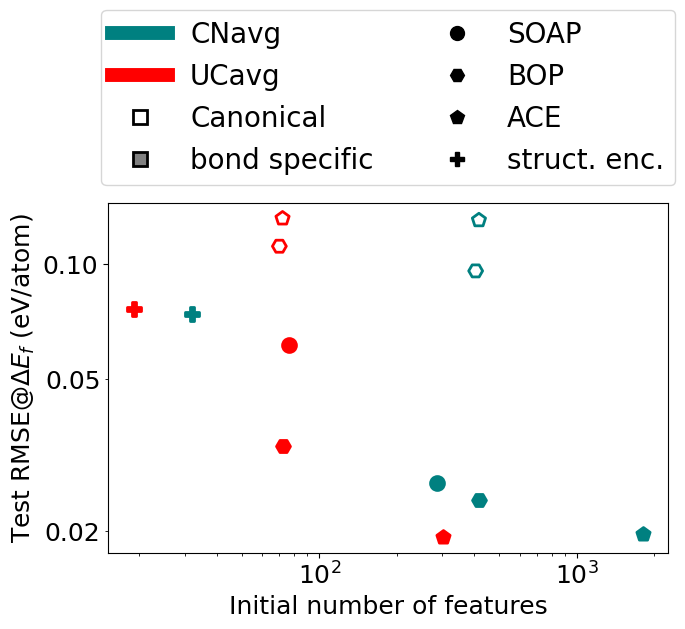

In [280]:
fig = plt.figure(figsize=(figw, figh*1.4))
axs = fig.add_axes([0.15, 0.1, 0.8, 0.5])
for (thedk, thetype, thecnav), data in VotedScores.groupby(['DK', 'type', 'iscnav']):
    if 'specific' in thedk:
        thefc=data['colors']
    else:
        thefc = 'none'
    axs.scatter(data['orig_len'], data['test'], ec=data['colors'], fc=thefc, linewidth=2, marker=markers[thetype], s=100)#, linewidth=linwidths[thedk]
axs.set_xscale('log')
axs.set_yscale('log', subs=[2,5,10])
axs.legend(handles=handles, bbox_to_anchor=(0.5,1.3), ncol=2, loc='center')
axs.yaxis.set_minor_formatter(FormatStrFormatter("%.2f"))
axs.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axs.set_xlabel('Initial number of features')
axs.set_ylabel('Test RMSE@$\Delta E_f$ (eV/atom)')
fig.savefig(f'{system}/graphs/Figure_{system}_VotedRegressor_{target_case}_{nameforfile}.pdf')

what we can add is a second panel with final num of features vs test rmse, and there we could see that for bop we remove less num of feat and we have a quite good final rmse with less features as with ACE. In the case of ACE the number of features taken out is also much bigger. 

In [281]:
VotedScores[~VotedScores.index.get_level_values(1).str.contains("^0.6|^0.8")]

test     train  orig_len   
Kernel Ridge 0.7dProjections 0.5OS BOP          0.024143  0.010088       417  \
             0.7dProjections 0.5OS BOP no CNAV  0.033361  0.023159        72   
             ACE                                0.019681  0.006712      1803   
             ACE no CNAV                        0.019317  0.009095       303   
             Canonical ACE                      0.130393  0.118325       417   
             Canonical ACE no CNAV              0.131793  0.118329        72   
             Canonical BOP                      0.096016  0.083104       405   
             Canonical BOP no CNAV              0.111438  0.089677        70   
             SOAP_specific_small                0.026742  0.011370       287   
             SOAP_specific_small no CNAV        0.061286  0.055295        76   
             dataset                            0.073894  0.057369        32   
             dataset no CNAV                    0.076093  0.078190        19   

                                                 iscnav                type   
Kernel Ridge 0.7dProjections 0.5OS BOP             CNAV                 BOP  \
             0.7dProjections 0.5OS BOP no CNAV  no CNAV                 BOP   
             ACE                                   CNAV                 ACE   
             ACE no CNAV                        no CNAV                 ACE   
             Canonical ACE                         CNAV                 ACE   
             Canonical ACE no CNAV              no CNAV                 ACE   
             Canonical BOP                         CNAV                 BOP   
             Canonical BOP no CNAV              no CNAV                 BOP   
             SOAP_specific_small                   CNAV                SOAP   
             SOAP_specific_small no CNAV        no CNAV                SOAP   
             dataset                               CNAV  structure encoding   
             dataset no CNAV                    no CNAV  structure encoding   

                                                       DK markers colors  
Kernel Ridge 0.7dProjections 0.5OS BOP           specific       H   teal  
             0.7dProjections 0.5OS BOP no CNAV   specific       H    red  
             ACE                                 specific       p   teal  
             ACE no CNAV                         specific       p    red  
             Canonical ACE                      canonical       p   teal  
             Canonical ACE no CNAV              canonical       p    red  
             Canonical BOP                      canonical       H   teal  
             Canonical BOP no CNAV              canonical       H    red  
             SOAP_specific_small                 specific       o   teal  
             SOAP_specific_small no CNAV         specific       o    red  
             dataset                             specific       P   teal  
             dataset no CNAV                     specific       P    red

In [282]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.get_level_values(1).str.contains('^0.6|^0.8')]

In [283]:
unstack = PlotVotedScores.unstack(level=0).sort_index()

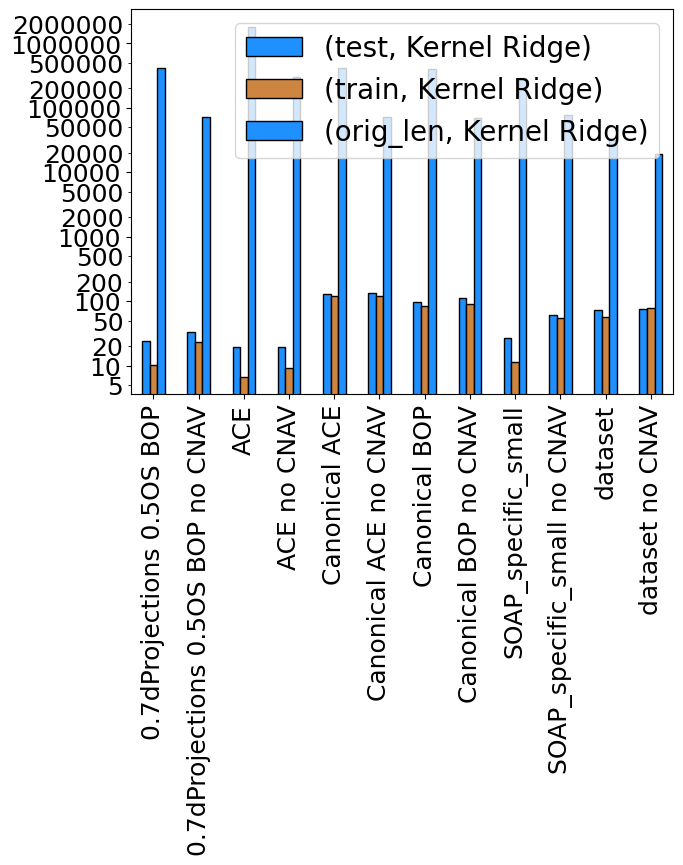

In [284]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru'], edgecolor = 'black'
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()
ax.set_yscale('log', subs=[2, 5, 10])
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Feature Importances 

In [285]:
thecase={
    'ACE': True,
    '0.7dProjections 0.5OS BOP': True,
    'SOAP_specific_small': True,
    'atomic': False,
    'dataset': False,
    'Canonical ACE': False,
    'Canonical BOP': False,
    'ACE no CNAV': False,
    '0.7spProjections 0.5OS BOP': False,
    'atomic no CNAV': False,
    'dataset no CNAV': False,
    '0.7dProjections 0.5OS BOP no CNAV': False,
    '0.7spProjections 0.5OS BOP no CNAV': False,
    'SOAP_specific_small no CNAV': False,
    'Canonical ACE no CNAV': False,
    'Canonical BOP no CNAV': False,
    'SOAP_canonicalW_small': False,
    'SOAP_canonicalW_small no CNAV': False
}

In [286]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')])

In [287]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')])

In [288]:
voting_regressor[(ModelName, 'SOAP_specific_small')].estimators[0][1].named_steps['feature_selection'].__dict__.keys()

dict_keys(['func', 'inverse_func', 'validate', 'accept_sparse', 'check_inverse', 'feature_names_out', 'kw_args', 'inv_kw_args'])

In [289]:
voting_regressor[(ModelName, 'SOAP_specific_small')].estimators[0][1].named_steps['feature_selection'].kw_args['learning_curve']#__dict__.keys()#['feature_names_out']

,train1,test1,params,test,train
SOAP_208_CN12,0.071192,0.071846,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.071697,0.071480
SOAP_11_CN12,0.060597,0.065868,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.064537,0.064486
SOAP_240_CN16,0.040255,0.079745,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.055392,0.048722
SOAP_212_0,0.033354,0.060270,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.049111,0.044783
Mag,0.021429,0.072221,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.043074,0.033907
...,...,...,...,...,...
SOAP_73_CN14,0.000097,0.042627,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.011136,0.005954
SOAP_114_CN15,0.000098,0.042671,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.011149,0.005970
SOAP_124_CN15,0.000099,0.042688,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.011163,0.005987
SOAP_74_CN14,0.000100,0.042703,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.011180,0.006003


In [290]:
voting_regressor[(ModelName, 'SOAP_specific_small')].estimators[1][1].named_steps['feature_selection'].kw_args['learning_curve'].iloc[:10]#__dict__.keys()#['feature_names_out']

,train1,test1,params,test,train
SOAP_206_CN12,0.081136,0.083186,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.086802,0.082692
SOAP_99_0,0.063704,0.071368,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.066541,0.064881
SOAP_208_0,0.041038,0.058598,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.053413,0.050733
SOAP_73_CN12,0.031179,0.056675,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.047250,0.046782
SOAP_35_CN13,0.028466,0.055778,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.044345,0.041784
SOAP_97_0,0.026896,0.056282,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.043331,0.040310
SOAP_76_CN14,0.025319,0.058318,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042430,0.038754
SOAP_84_CN12,0.024802,0.059858,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042317,0.038451
SOAP_201_CN15,0.024626,0.058582,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042097,0.037672
SOAP_82_CN12,0.024567,0.060954,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.041302,0.035083


In [291]:
voting_regressor[(ModelName, 'SOAP_specific_small')].estimators[2][1].named_steps['feature_selection'].kw_args['learning_curve'].iloc[:10]#__dict__.keys()#['feature_names_out']

,train1,test1,params,test,train
SOAP_208_CN12,0.071236,0.072339,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.071728,0.071480
SOAP_11_CN12,0.060665,0.066009,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.064537,0.064486
SOAP_242_CN16,0.039410,0.065388,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.055978,0.051192
SOAP_209_CN12,0.034803,0.098739,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.048489,0.044937
SOAP_214_CN14,0.028505,0.081098,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.045036,0.042687
Mag,0.015054,0.072049,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.040550,0.035535
SOAP_137_CN16,0.012572,0.066487,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.034859,0.034675
SOAP_99_CN12,0.007977,0.064745,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.031421,0.029574
SOAP_7_0,0.003381,0.060359,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.029664,0.025794
SOAP_92_CN14,0.000898,0.065572,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.029670,0.017185


In [292]:
voting_regressor[(ModelName, 'SOAP_specific_small')].estimators[3][1].named_steps['feature_selection'].kw_args['learning_curve'].iloc[:10]#__dict__.keys()#['feature_names_out']

,train1,test1,params,test,train
SOAP_208_CN12,0.071276,0.070517,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.071717,0.071480
SOAP_238_CN16,0.057343,0.070981,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.062790,0.057892
SOAP_87_0,0.044281,0.083431,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.052165,0.051139
SOAP_4_CN12,0.033017,0.059164,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.049501,0.045875
SOAP_139_CN16,0.031674,0.062828,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.044085,0.043621
SOAP_204_CN14,0.027066,0.080357,"{'regressor__alpha': 0.01, 'regressor__coef0':...",0.041316,0.040658
SOAP_179_CN12,0.025423,0.083659,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.041736,0.040582
SOAP_12_CN13,0.025240,0.064814,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.040910,0.039946
SOAP_131_CN14,0.024955,0.075955,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.040505,0.038678
SOAP_37_CN14,0.024082,0.062765,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.040372,0.037042


In [293]:
voting_regressor[(ModelName,'SOAP_specific_small')].estimators[1][1].named_steps['feature_selection'].kw_args['learning_curve'].iloc[:10]#__dict__.keys()#['feature_names_out']

,train1,test1,params,test,train
SOAP_206_CN12,0.081136,0.083186,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.086802,0.082692
SOAP_99_0,0.063704,0.071368,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.066541,0.064881
SOAP_208_0,0.041038,0.058598,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.053413,0.050733
SOAP_73_CN12,0.031179,0.056675,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.047250,0.046782
SOAP_35_CN13,0.028466,0.055778,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.044345,0.041784
SOAP_97_0,0.026896,0.056282,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.043331,0.040310
SOAP_76_CN14,0.025319,0.058318,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042430,0.038754
SOAP_84_CN12,0.024802,0.059858,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042317,0.038451
SOAP_201_CN15,0.024626,0.058582,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.042097,0.037672
SOAP_82_CN12,0.024567,0.060954,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.041302,0.035083


In [294]:
def _sanitize_cache_token(name: str) -> str:
    # Keep cache filenames portable and deterministic.
    return name.replace(' ', '').replace('/', '-').replace('\\', '-').replace(':', '-')


def _compute_or_load_importance(combi_and_estimator):
    (modelname, featurename), estimator = combi_and_estimator
    if not thecase.get(featurename, False):
        return (modelname, featurename), None

    safe_model = _sanitize_cache_token(modelname)
    safe_feature = _sanitize_cache_token(featurename)
    cache_file = os.path.join(
        importances_cache_dir,
        f"importance_{safe_model}_{safe_feature}.pkl"
    )

    if os.path.exists(cache_file):
        timportances = pd.read_pickle(cache_file)
        return (modelname, featurename), timportances

    X = DS.Features[featurename]
    timportances = get_importances(estimator, X, DS.target)
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    timportances.to_pickle(cache_file)
    return (modelname, featurename), timportances


def loop_get_importances(voting_regressor, n_jobs=None):
    selected_estimators = [
        (combi, estimator)
        for combi, estimator in voting_regressor.items()
        if thecase.get(combi[1], False)
    ]
    if len(selected_estimators) == 0:
        return {}

    if n_jobs is None:
        n_jobs = N_JOBS_IMPORTANCES

    computed = joblib.Parallel(n_jobs=n_jobs, backend=JOBLIB_BACKEND)(
        joblib.delayed(_compute_or_load_importance)(item)
        for item in selected_estimators
    )
    return {combi: timportances for combi, timportances in computed if timportances is not None}

In [295]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

In [296]:
if CALC_IMPORTANCES in os.environ:
    importances_cache_dir = os.path.join(DS.dataset, 'results', 'importances')
    os.makedirs(importances_cache_dir, exist_ok=True)

    importances_file = os.path.join(
        DS.dataset,
        'results',
        f"{ModelName.replace(' ', '')}_importances.pkl"
    )

    importances_dict = loop_get_importances(voting_regressor, n_jobs=N_JOBS_IMPORTANCES)
    if len(importances_dict) > 0:
        importances = pd.concat(importances_dict, axis=0)
        importances.to_pickle(importances_file)
    else:
        importances = pd.DataFrame()
        print('No enabled feature set in thecase; importances is empty.')
else:
    print('Calculation of importances SKIPPED')

Calculation of importances SKIPPED


In [297]:
if  CALC_IMPORTANCES in os.environ:
    descritor_inseterest = ['ACE','0.7dProjections 0.5OS BOP', 'SOAP_specific_small' ]
    nfeatures  = 20
    fw, fh = plt.rcParams['figure.figsize']
    nplots = 3
    axw = 1/nplots
    #fig, ax = plt.subplots(1, 2*nplots, figsize=(fw*2*nplots, fh*nfeatures/10))
    fig = plt.figure(figsize=(fw*nplots*0.8, fh*nfeatures/2))
    for i, descriptor in enumerate(descritor_inseterest):
        axr = 2*(i+1)*axw
        axl = axr-axw
        thisax = fig.add_axes([axl, 0.1, axw, 0.8])
        this_importances = importances.loc[(ModelName, descriptor)]['importances_mean'].sort_values(ascending=False)
        thisax.barh(this_importances.index[:nfeatures], this_importances.values[:nfeatures])
    fig.supxlabel('permutation importance', fontsize=28, x=1)
else:
    print('Plot of importances bypassed')

Plot of importances bypassed


In [298]:
if CALC_IMPORTANCES in os.environ:
    for combi, bag_of_curves in FCresults.items():
        if combi not in importances.keys():
            continue
    #    if '0.7dProjections 0.5OS BOP' in combi:
    #        break

        relevant_importances = importances[combi].query('importances_mean > 0')/importances[combi].max()
        nrelevant = len(relevant_importances)

        locs = {}

        for featurename, importance in relevant_importances.iterrows():
            locs[featurename] = {i: curve.index.get_loc(featurename) for i, curve in enumerate(bag_of_curves) if featurename in curve.index}
                
        locs = pd.DataFrame.from_dict(locs, orient='index')#, dtype= int)
        locs['mean'] = locs.mean(axis=1)
        locs.sort_values(by='mean', inplace=True)
        locs['std'] = locs.drop(columns=['mean']).std(axis = 1)
        locs.dropna(inplace=True)
        if len(locs) == 0:
            continue
        indexing = pd.Series(np.linspace(0, len(relevant_importances)-1, len(relevant_importances)), index=relevant_importances.index, name='indexing')
        indexed_locs = pd.concat([indexing, locs], axis=1)
        fig, ax = plt.subplots(figsize=(8,0.5*(nrelevant+1)))
        fig.suptitle(f'{combi}', x=0, fontsize=12)
        axup= ax.twiny()
        ax.barh(y = indexing, width=relevant_importances['importances_mean'])
        axup.stem(indexed_locs['indexing'],indexed_locs['mean'],  orientation='horizontal', linefmt='r', markerfmt='dr')
        #axup.stem(indexing[locs.index],locs['mean'],  orientation='horizontal', linefmt='b', markerfmt='o')
        axup.set_xlim([0, locs['mean'].max()])
        axup.set_xlabel('position in selection vector')
        ax.set_yticks(indexing)
        labels = ax.set_yticklabels(relevant_importances.index)
        axup.spines['top'].set_color('red')
        #locs.plot(x='std')
        #axs[0].set_xscale('log')
    else: 
        print('skip plot importances')

# Prediction line 

In [299]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [300]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [301]:
predictions={}
stds={}
Prediction = {} 

In [302]:
for name, regressor in voting_regressor.items():
    if name[1] not in Features:
        continue
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [303]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [304]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [305]:
predictedBS.filter(regex='EF_nmhcp_*')

,EF_nmhcp,EF_nmhcp_atomic,EF_nmhcp_dataset,EF_nmhcp_Canonical ACE,EF_nmhcp_Canonical BOP,EF_nmhcp_ACE no CNAV,EF_nmhcp_ACE,EF_nmhcp_0.7dProjections 0.5OS BOP,EF_nmhcp_atomic no CNAV,EF_nmhcp_dataset no CNAV,EF_nmhcp_0.7dProjections 0.5OS BOP no CNAV,EF_nmhcp_SOAP_specific_small,EF_nmhcp_SOAP_specific_small no CNAV,EF_nmhcp_Canonical ACE no CNAV,EF_nmhcp_Canonical BOP no CNAV
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.478663,0.317807,0.497686,0.371913,0.413230,0.503615,0.499730,0.489973,0.319185,0.401861,0.498533,0.497078,0.439894,0.370660,0.424118
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.133919,0.276964,0.139546,0.177610,0.163943,0.139830,0.132260,0.135539,0.277815,0.121363,0.129528,0.131847,0.155889,0.166185,0.168812
Fe_pv2Mo_sv11.mu-BBABB.FM,0.403272,0.322634,0.424106,0.354286,0.452872,0.410980,0.403910,0.403301,0.324077,0.411567,0.417403,0.407194,0.356018,0.348153,0.496586
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.058290,0.282382,0.079736,0.210090,0.171466,0.056251,0.061035,0.062937,0.283300,0.072436,0.077852,0.059027,0.166285,0.232297,0.207179
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.363607,0.322634,0.365194,0.379887,0.394643,0.381454,0.373487,0.363142,0.324077,0.307044,0.400201,0.370299,0.356307,0.392092,0.489856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv30.sigma.FM,0.075258,0.143010,0.121051,0.147581,0.131487,0.061327,0.077467,0.103105,0.143319,0.135043,0.116058,0.077958,0.123581,0.169362,0.078501
Fe_pv6.C15.FM,0.144169,0.143010,0.152880,0.197381,0.229290,0.163961,0.161804,0.159558,0.143319,0.247013,0.154203,0.151431,0.169968,0.192508,0.187018
Mo_sv8.A15.NM,0.095306,0.340886,0.146893,0.152909,0.109628,0.092943,0.095666,0.095942,0.337759,0.151922,0.101616,0.094874,0.230697,0.173571,0.105514
Mo_sv6.C15.NM,0.367463,0.340886,0.353702,0.419843,0.389307,0.368227,0.363050,0.367872,0.337759,0.364418,0.372495,0.371000,0.335508,0.413954,0.362755


## save the prediction

In [306]:
#predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))


In [307]:
iwanttoplot = {
#    'dataset': 'atomic+oneHot',
    test_bop_feature:'Bond specific BOP',
    'ACE': 'ACE',
#    'SOAP_specific_small': 'SOAP'
}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

In [308]:
iwanttoplot

{'0.7dProjections 0.5OS BOP': 'Bond specific BOP', 'ACE': 'ACE'}

In [309]:
Prediction.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV')])

0.7dProjections 0.5OS BOP Bond specific BOP
ACE ACE


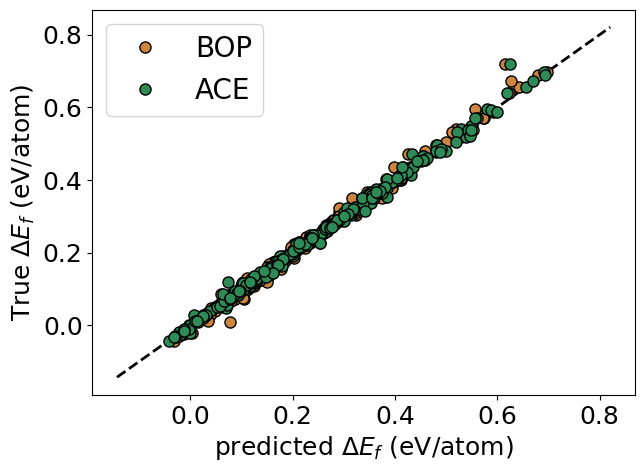

In [310]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots()
ax.plot(x_y, x_y, '--k', lw=2)

# Local color map for prediction-line plot (independent from CNAV colors used above).
plot_colors = {
    'dataset': 'dodgerblue',
    test_bop_feature: 'peru',
    'ACE': 'seagreen',
    'SOAP_specific_small': 'darkorange',
}

for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra').replace('Bond specific BOP', 'BOP')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    intersection = Prediction[combi].index.intersection(DS.target.index)
    ax.plot(
        Prediction[combi].loc[intersection],
        DS.target.loc[intersection],
        'o',
        markersize=8,
        markeredgecolor='k',
        color=plot_colors.get(name, 'gray'),
        label=legend,
    )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

In [311]:
combi

('Kernel Ridge', 'ACE')

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [312]:
Tester = DatasetTester()

In [313]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [314]:
import copy

In [315]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [316]:
ReducedFittedModels = {}

In [317]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [318]:
#if os.path.exists(Reduced_features_fitting_location):
#    with open(Reduced_features_fitting_location, 'rb') as pkl:
#        ReducedFittedModels = pickle.load(pkl)

In [319]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

In [320]:
DORECURSIVE = 'DORECURSIVE'

In [321]:
if os.getenv(DORECURSIVE) is not None:
    maxorders = [8, 10, 12, 14, 16]
    for name, model in Models.items():
        if name != ModelName:
            continue
        progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
        for (key, features), maxorder in progress:  # maxorder in range(4,9):
            progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
            if (name, key, maxorder) in ReducedFittedModels.keys():
                continue
            if 'no CNAV' in key:
                continue
            if 'BOP' not in key:
                continue
            if 'Projections' not in key:
                continue
            if (name, key, maxorder) in ReducedFittedModels.keys():
                continue
            if maxorder < 10:
                regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
            else:
                regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
    #        for key, features in progress: #Features.items():
            model = GridSearchCV(
                Models[name],
                MO.modeloptions[name], 
                scoring='neg_root_mean_squared_error', 
                cv = 5,#samplefolds,
                return_train_score= True,
            )
            if 'BOP' in key:
                reducedfeatures = features.filter(regex=regexstr)
            else:
                reducedfeatures = features
            ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)
    with open(Reduced_features_fitting_location, 'wb') as pkl:
        pickle.dump(ReducedFittedModels, pkl)

In [322]:
somecombi = (ModelName, 'Projections BOP')

In [323]:
ReducedFittedModels.keys()

dict_keys([])

In [324]:
somecombi

('Kernel Ridge', 'Projections BOP')

In [325]:
#features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(8,)].feature_names_in_)

In [326]:
if os.getenv(DORECURSIVE):
    best_scores_reduced = collect_best_scores(ReducedFittedModels)
    model = best_scores_reduced.index.get_level_values(0)
    test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)
    full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

In [327]:
if os.getenv(DORECURSIVE):# in os.environ:
    fig, ax = plt.subplots(figsize=(15, 8))
    for combi in test_scores_vs_max.columns:
    #    if 'BOP' not in combi[1]:
    #        continue
    #    if 'Canonical' in combi[1]:
    #        continue
    #    if 'dataset' not in combi[1]:
    #        continue
        drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
        l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
    #    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
    ax.legend(bbox_to_anchor = (1, 1))
    ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
    ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
    fig.tight_layout()
    fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Errors by phase by model

In [328]:
train_errors = {}
rmse = {}

In [329]:
absolute_errors = {}

In [330]:
iwanttoseeerrors = ['0.7dProjections 0.5OS BOP', 'SOAP_specific_small', 'ACE']

In [331]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    #if 'sOS' in combi[1]:
    #    continue
    if combi[1] not in iwanttoseeerrors:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

('Kernel Ridge', 'ACE')
('Kernel Ridge', '0.7dProjections 0.5OS BOP')
('Kernel Ridge', 'SOAP_specific_small')


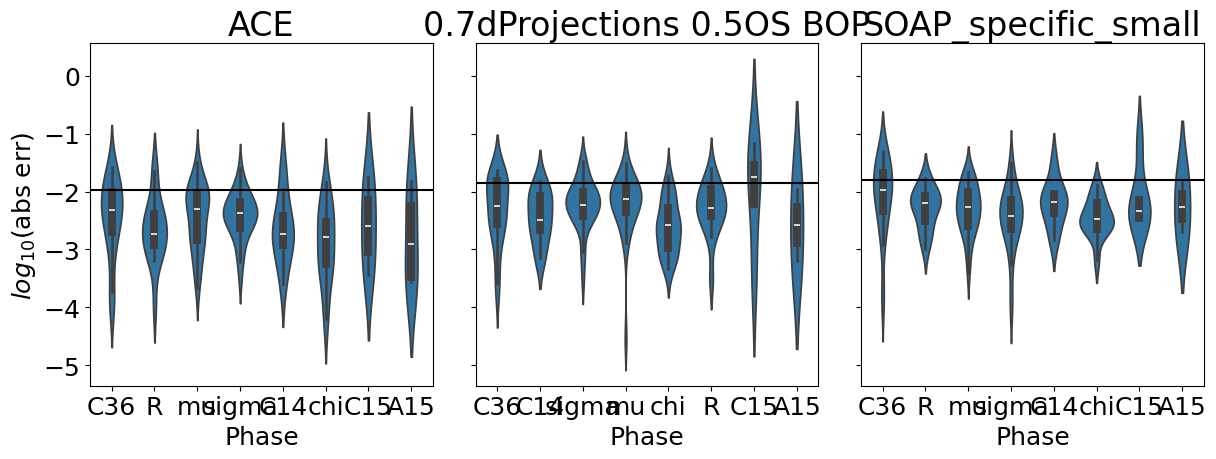

In [ ]:
width = plt.rcParams['figure.figsize'][0]*len(iwanttoseeerrors)*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, len(rmse),sharey=True, figsize=(width, height))

for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        y=absolute_errors[combi][target_case].map(np.log10), 
        x=DS.StructureNames, ax=ax
    )#hue=DS.Features['dataset']['Mag'],,  split=True
    ax.axhline(np.log10(rmse[combi]['total']),color='k', label='rmse')
#    ax.get_legend().remove()
    ax.set_ylabel(combi[1].replace('_specific', ''))
    ax.set_title( combi[1] )
axes[0].set_ylabel('$log_{10}$(abs err)')
fig.tight_layout()

In [ ]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [ ]:
rmsedf.sort_values(by=(ModelName, '0.7dProjections 0.5OS BOP'), axis = 1, inplace=True)

In [ ]:
rmsedf.sort_values(by='total', inplace=True)

In [ ]:
important = [(ModelName, '0.7dProjections 0.5OS BOP'), (ModelName, 'ACE'), (ModelName, 'SOAP_specific_small')]

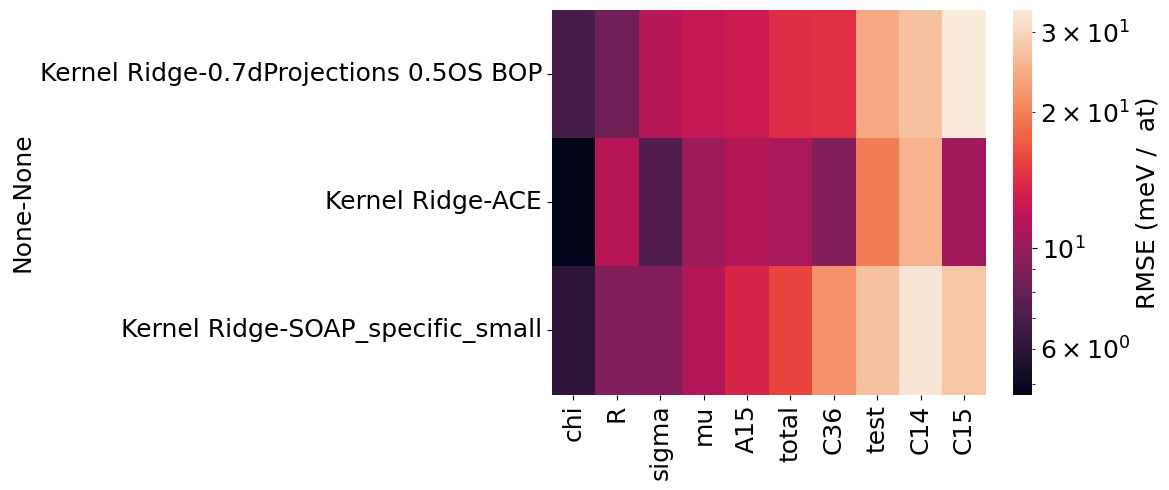

In [ ]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[important]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())